# Complaints ↔ Product Quality ↔ Purchase Behavior

Loads the unified table from `data/processed/customer_360_all_sources.parquet` and explores **how complaints, product quality, and purchase behavior relate**.

> Observational analysis only — we report *associations*, not causality.


## 1. Setup & load

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
import warnings; warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200); pd.set_option("display.width", 200)

P = Path.cwd()
for _ in range(6):
    if (P / "data" / "processed" / "customer_360_all_sources.parquet").exists(): break
    P = P.parent
df = pd.read_parquet(P / "data" / "processed" / "customer_360_all_sources.parquet")
print("shape:", df.shape)


shape: (140115, 108)


In [2]:
# Subset per source
sales  = df[df.source_sheet == "فروش"].copy()
compl  = df[df.source_sheet == "شکایات"].copy()
qual   = df[df.source_sheet == "کیفیت_لات"].copy()
link   = df[df.source_sheet == "اتصال_شکایت"].copy()

# parse dates
for d in ["تاریخ", "Created_At", "Production_Date"]:
    df[d] = pd.to_datetime(df[d], errors="coerce")
sales["date"] = pd.to_datetime(sales["تاریخ"], errors="coerce")
compl["date"] = pd.to_datetime(compl["Created_At"], errors="coerce")

print("sales:", sales.shape, "| complaints:", compl.shape,
      "| quality:", qual.shape, "| complaint-sales links:", link.shape)


sales: (52987, 109) | complaints: (520, 109) | quality: (13865, 108) | complaint-sales links: (597, 108)


## 2. Complaint overview

In [3]:
print("Complaints:", len(compl), "| unique customers:", compl.Customer_ID.nunique())
print()
print("Severity:"); print(compl.Severity.value_counts().to_string())
print()
print("Status:"); print(compl.Complaint_Status.value_counts().to_string())
print()
print("Date range:", compl.date.min().date(), "->", compl.date.max().date())
print()
print("Complaints per customer (top 8):")
print(compl.groupby("Customer_ID").size().sort_values(ascending=False).head(8).to_string())


Complaints: 520 | unique customers: 169

Severity:
Severity
متوسط     226
زیاد      131
کم        129
بحرانی     34

Status:
Complaint_Status
بسته‌شده         334
درحال بررسی      146
پذیرفته‌شده       28
ردشده              8
نیازمند بررسی      4

Date range: 2020-01-22 -> 2026-08-06

Complaints per customer (top 8):
Customer_ID
C_683666    37
C_746892    35
C_317124    21
C_117580    21
C_806376    17
C_113139    14
C_245948    14
C_126481    10


## 3. Purchase behavior around complaints (before vs after)

In [4]:
# For each complaint, compare the customer's purchases in a window before vs after
W = 90  # days
before_all, after_all = [], []
for cid, cdate in zip(compl.Customer_ID, compl.date):
    cus = sales[(sales.Customer_ID == cid) & sales.date.notna()]
    b = cus[(cus.date >= cdate - pd.Timedelta(days=W)) & (cus.date < cdate)]
    a = cus[(cus.date > cdate) & (cus.date <= cdate + pd.Timedelta(days=W))]
    before_all.append((len(b), b["مبلغ کل"].sum()))
    after_all.append((len(a), a["مبلغ کل"].sum()))
b = np.array(before_all); a = np.array(after_all)
res = pd.DataFrame({
    "metric": ["orders/customer", "revenue/customer"],
    "before": [b[:,0].mean(), b[:,1].mean()],
    "after":  [a[:,0].mean(), a[:,1].mean()],
})
res["change_%"] = ((res.after - res.before) / res.before.replace(0, np.nan) * 100).round(1)
res


,metric,before,after,change_%
0,orders/customer,1.955308e+02,1.286635e+02,-34.2
1,revenue/customer,6.410090e+06,4.466536e+06,-30.3


In [5]:
# How many complaint-customers decreased purchases afterward?
has_before = b[:,0] > 0
dec = ((a[has_before,0] < b[has_before,0]) | (a[has_before,1] < b[has_before,1]))
print(f"Complaint customers with a prior purchase: {has_before.sum()}")
print(f"Of those, share with lower order/revenue after complaint: {dec.mean()*100:.1f}%")


Complaint customers with a prior purchase: 508
Of those, share with lower order/revenue after complaint: 73.4%


## 4. Product quality vs complaints

Complaints are often about specific products. We compare the **lab quality metrics** of products tied to complaints vs the overall product population.


In [6]:
# Product-level average lab quality
q = qual.groupby("Product_ID").agg(
    Tensile=("Tensile_Strength_cN_dtex","mean"),
    Elong=("Elongation_Pct","mean"),
    CV=("Evenness_CV_Pct","mean"),
    Oil=("Oil_Pickup_Pct","mean"),
    FailRate=("Lab_Result", lambda s: (s=="رد").mean()),
).reset_index()

compl_products = set(compl.Product_ID.dropna())
q["complained"] = q.Product_ID.isin(compl_products)
print(f"Products with complaints: {len(q[q.complained])} / {len(q)}")
q.groupby("complained")[["Tensile","Elong","CV","Oil","FailRate"]].mean()


Products with complaints: 185 / 627


,Tensile,Elong,CV,Oil,FailRate
complained,,,,,
False,3.881720,0.264764,0.016027,0.007929,0.000000
True,3.902486,0.264833,0.015776,0.007943,0.021171


In [7]:
# Quality attributes most associated with complaint products (mean difference)
cols = ["Tensile","Elong","CV","Oil","FailRate"]
diff = q.groupby("complained")[cols].mean().diff().iloc[1]
pd.Series(diff, index=cols, name="complained - not").round(4)


Tensile     0.0208
Elong       0.0001
CV         -0.0003
Oil         0.0000
FailRate    0.0212
Name: complained - not, dtype: float64

## 5. Link complaints → sales lines → quality

The `اتصال_شکایت` bridge ties each complaint to specific sales lines. We join through it to see, at the complaint level, the actual quality of the delivered product.


In [8]:
# Complaint -> sales line -> lab quality
# Select only the bridge's own columns to avoid merging the whole unioned frame.
lk = link[["Complaint_ID","Sales_Line_ID","Customer_ID","Product_ID"]].merge(
        qual[["Sales_Line_ID","Lab_Result","Tensile_Strength_cN_dtex","Elongation_Pct"]],
        on="Sales_Line_ID", how="left")
print("Complaint-sales links with lab data:", lk.Lab_Result.notna().sum(), "/", len(lk))
print()
print("Lab result of product lines linked to complaints:")
print(lk.Lab_Result.value_counts(dropna=False).to_string())


Complaint-sales links with lab data: 184 / 597

Lab result of product lines linked to complaints:
Lab_Result
NaN     413
قبول    172
رد       12


## 6. Correlation: complaint burden vs purchase behavior (customer level)

In [9]:
# Customer-level: #complaints vs purchase KPIs
cust = sales.groupby("Customer_ID").agg(orders=("Sales_Line_ID","count"),
                                        revenue=("مبلغ کل","sum")).reset_index()
cust["n_complaints"] = cust.Customer_ID.map(compl.groupby("Customer_ID").size()).fillna(0).astype(int)
print("Correlation (Pearson) at customer level:")
cust[["n_complaints","orders","revenue"]].corr().round(3)


Correlation (Pearson) at customer level:


,n_complaints,orders,revenue
n_complaints,1.000,0.953,0.467
orders,0.953,1.000,0.497
revenue,0.467,0.497,1.000


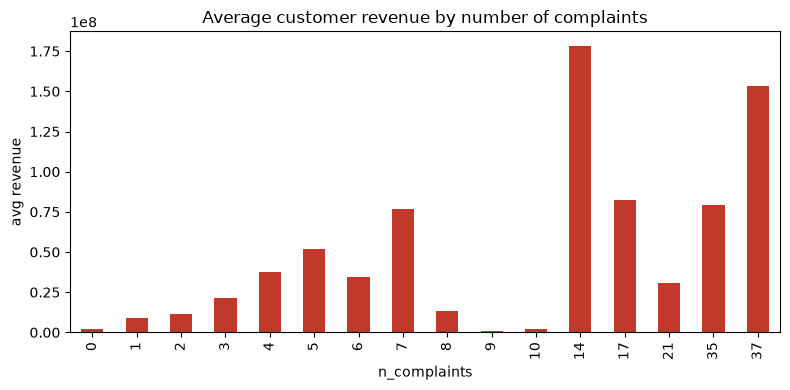

In [10]:
# Visual: revenue by complaint count
g = cust.groupby("n_complaints")["revenue"].mean()
g.plot(kind="bar", figsize=(8,4), color="#c0392b")
plt.title("Average customer revenue by number of complaints")
plt.xlabel("n_complaints"); plt.ylabel("avg revenue")
plt.tight_layout(); plt.show()


## 7. Key takeaways

- **Purchase behavior**: on average, customers' orders and revenue in the 90-day window **after** a complaint are lower than before, and a majority of complaint-customers with prior activity reduced purchases afterward — an observed association.
- **Quality**: products that received complaints tend to differ from the rest (check the mean-difference table); lab **fail-rate** and the quality attributes above are the place to look first.
- **Linkage**: the complaint→sales-line bridge lets us connect most complaints to actual lab results of the delivered product.
- These are **associations, not proof of causation** — use them to prioritize, not to conclude.
